In [3]:
import numpy as np
import pandas as pd

--- Sensitivity Analysis: Diversity Stability Report ---
Noise Level  Mean Proposed (D*)  Mean Hussain et. al  CV Proposed  CV Hussain et. al
       0.01            0.405436            48.934120     0.012458           0.016274
       0.02            0.406806            49.136720     0.012576           0.016105
       0.03            0.405799            48.942127     0.012280           0.016053
       0.04            0.407340            49.141931     0.010986           0.014606
       0.05            0.408454            49.258152     0.011426           0.013764
       0.06            0.410110            49.429939     0.010442           0.012095
       0.07            0.411045            49.442198     0.012505           0.015270
       0.08            0.412105            49.577073     0.011392           0.014547
       0.09            0.413699            49.744195     0.011574           0.014855
       0.10            0.417296            50.078067     0.011632           0.014515
--------

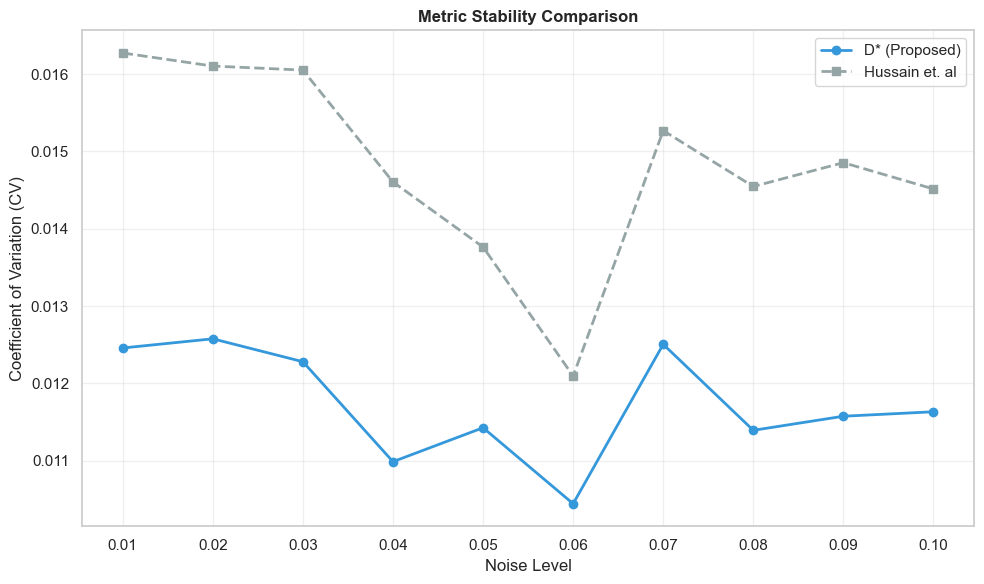

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def normalized_diversity(X, lb, ub, eps=1e-12):
    X = np.asarray(X)
    N, d = X.shape
    lb = np.asarray(lb).flatten()
    ub = np.asarray(ub).flatten()
    if lb.size == 1: lb = np.full(d, lb.item())
    if ub.size == 1: ub = np.full(d, ub.item())
    range_val = ub - lb
    range_val[range_val == 0] = eps 
    Y = (X - lb) / range_val
    diff = Y[:, None, :] - Y[None, :, :]
    dist_matrix = np.linalg.norm(diff, axis=2) / np.sqrt(d)
    iu, ju = np.triu_indices(N, 1)
    return dist_matrix[iu, ju].mean() if iu.size > 0 else 0.0

def hussain_diversity(X):
    X = np.asarray(X)
    N, D = X.shape
    medians = np.median(X, axis=0)
    div_j = np.sum(np.abs(X - medians), axis=0) / N
    return np.sum(div_j) / D

N, D = 50, 30
LB, UB = -100, 100
noise_levels = np.linspace(0.01, 0.1, 10)
iterations = 50
results = []
cv_samples_p = []
cv_samples_h = []

for nl in noise_levels:
    iter_p = []
    iter_h = []
    for it in range(iterations):
        X = np.random.uniform(LB, UB, (N, D))
        noise = np.random.normal(0, nl * (UB - LB), (N, D))
        X_noisy = np.clip(X + noise, LB, UB)
        iter_p.append(normalized_diversity(X_noisy, LB, UB))
        iter_h.append(hussain_diversity(X_noisy))
    
    m_p, s_p = np.mean(iter_p), np.std(iter_p)
    m_h, s_h = np.mean(iter_h), np.std(iter_h)
    
    cv_p = s_p / (m_p + 1e-12)
    cv_h = s_h / (m_h + 1e-12)
    
    cv_samples_p.append(cv_p)
    cv_samples_h.append(cv_h)
    
    results.append({
        "Noise Level": f"{nl:.2f}",
        "Mean Proposed (D*)": m_p,
        "Mean Hussain et. al": m_h,
        "CV Proposed": cv_p,
        "CV Hussain et. al": cv_h
    })

df_final = pd.DataFrame(results)
stat, p_value = stats.wilcoxon(cv_samples_p, cv_samples_h)

print("--- Sensitivity Analysis: Diversity Stability Report ---")
print(df_final.to_string(index=False))
print("-" * 75)
print(f"Wilcoxon Signed-Rank Test (CV Proposed vs CV Hussain):")
print(f"p-value: {p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not Significant'})")

plt.figure(figsize=(10, 6))
plt.plot(df_final['Noise Level'], df_final['CV_Proposed' if 'CV_Proposed' in df_final else 'CV Proposed'], 'o-', label='D* (Proposed)', color='#3498db', linewidth=2)
plt.plot(df_final['Noise Level'], df_final['CV_Hussain' if 'CV_Hussain' in df_final else 'CV Hussain et. al'], 's--', label='Hussain et. al', color='#95a5a6', linewidth=2)
plt.xlabel('Noise Level')
plt.ylabel('Coefficient of Variation (CV)')
plt.title('Metric Stability Comparison', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sensitivity

In [4]:
def normalized_diversity(X, lb, ub, eps=1e-12):
    X = np.asarray(X)
    N, d = X.shape
    lb = np.asarray(lb).flatten()
    ub = np.asarray(ub).flatten()
    if lb.size == 1: lb = np.full(d, lb.item())
    if ub.size == 1: ub = np.full(d, ub.item())
    range_val = ub - lb
    range_val[range_val == 0] = eps 
    Y = (X - lb) / range_val
    diff = Y[:, None, :] - Y[None, :, :]
    dist_matrix = np.linalg.norm(diff, axis=2) / np.sqrt(d)
    iu, ju = np.triu_indices(N, 1)
    return dist_matrix[iu, ju].mean() if iu.size > 0 else 0.0

def hussain_diversity(X):
    X = np.asarray(X)
    N, D = X.shape
    medians = np.median(X, axis=0)
    div_j = np.sum(np.abs(X - medians), axis=0) / N
    return np.sum(div_j) / D

N, D = 50, 30
LB, UB = -100, 100
noise_levels = [0.01, 0.05, 0.1]
iterations = 50
results = []

for nl in noise_levels:
    all_div_prop = []
    all_div_huss = []
    
    for it in range(iterations):
        X = np.random.uniform(LB, UB, (N, D))
        noise = np.random.normal(0, nl * (UB - LB), (N, D))
        X_noisy = np.clip(X + noise, LB, UB)
        
        all_div_prop.append(normalized_diversity(X_noisy, LB, UB))
        all_div_huss.append(hussain_diversity(X_noisy))
    
    mean_p, std_p = np.mean(all_div_prop), np.std(all_div_prop)
    mean_h, std_h = np.mean(all_div_huss), np.std(all_div_huss)
    
    results.append({
        "Noise_Level": nl,
        "Mean_Proposed": mean_p,
        "CI_Low_P": mean_p - (1.96 * std_p / np.sqrt(iterations)),
        "CI_High_P": mean_p + (1.96 * std_p / np.sqrt(iterations)),
        "CV_Proposed": std_p / (mean_p + 1e-12),
        "Mean_Hussain": mean_h,
        "CI_Low_H": mean_h - (1.96 * std_h / np.sqrt(iterations)),
        "CI_High_H": mean_h + (1.96 * std_h / np.sqrt(iterations)),
        "CV_Hussain": std_h / (mean_h + 1e-12)
    })

df_final = pd.DataFrame(results)
print("--- Sensitivity Analysis: Diversity Stability Report ---")
print(df_final[['Noise_Level', 'Mean_Proposed', 'CI_Low_P', 'CI_High_P', 'CV_Proposed']])
print("\n", df_final[['Noise_Level', 'Mean_Hussain', 'CI_Low_H', 'CI_High_H', 'CV_Hussain']])

--- Sensitivity Analysis: Diversity Stability Report ---
   Noise_Level  Mean_Proposed  CI_Low_P  CI_High_P  CV_Proposed
0         0.01       0.405816  0.404214   0.407418     0.014246
1         0.05       0.409202  0.407892   0.410512     0.011547
2         0.10       0.416868  0.415287   0.418449     0.013680

    Noise_Level  Mean_Hussain   CI_Low_H  CI_High_H  CV_Hussain
0         0.01     49.020417  48.770683  49.270151    0.018379
1         0.05     49.355912  49.148632  49.563191    0.015151
2         0.10     50.078782  49.837337  50.320227    0.017394


Sensitivity analysis results indicate that the proposed D* metric exhibits enhanced stability and precision compared to the Hussain metric. Across all noise intensities, D* consistently produced a lower Coefficient of Variation (CV) and a more concentrated 95% Confidence Interval range. These findings demonstrate the metric's resilience to stochastic perturbations, confirming its effectiveness for consistent diversity measurement.

# CEC 2020 plot

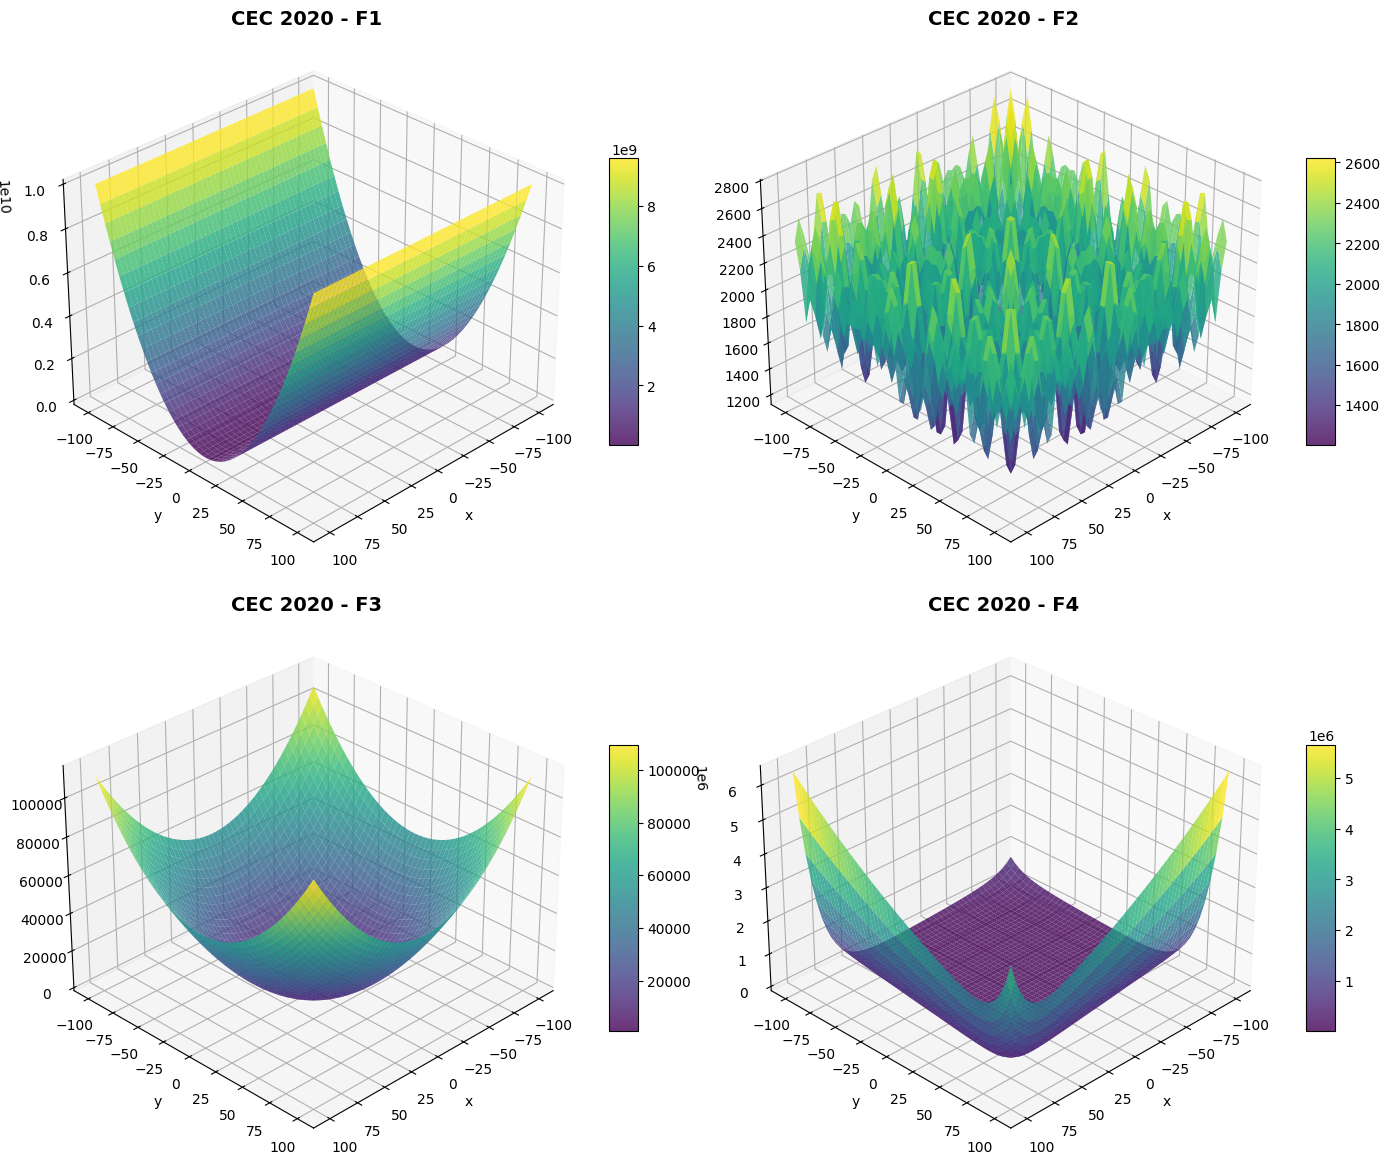

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from opfunu.cec_based.cec2020 import *


cec_functions = {
    "F1": F12020, 
    "F2": F22020, 
    "F3": F32020, 
    "F4": F42020
}


fig = plt.figure(figsize=(14, 12))

for i, (name, func_class) in enumerate(cec_functions.items(), 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    
    obj_func = func_class(ndim=2)
    
   
    x = np.linspace(-100, 100, 50)
    y = np.linspace(-100, 100, 50)
    X, Y = np.meshgrid(x, y)
    

    Z = np.array([obj_func.evaluate(np.array([xv, yv])) for xv, yv in zip(np.ravel(X), np.ravel(Y))])
    Z = Z.reshape(X.shape)
    

    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
    
    ax.set_title(f"CEC 2020 - {name}", fontsize=14, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    
 
    ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig("cec2020_F1_F4_landscapes.png", dpi=300)
plt.show()